In [39]:
import pandas as pd # 파이썬 프로그래밍 언어 > 행.열 기반으로 되어있는 테이블 형태로 자료구조 생성하도록 지원하는 모듈

FILE_PATH = "연관키워드 20260921 1347.xlsx"

df = pd.read_excel(FILE_PATH, header=1)

df.head()

,Unnamed: 0,월간검색수(PC),월간검색수(모바일),월평균클릭수(PC),월평균클릭수(모바일),월평균클릭률(PC),월평균클릭률(모바일),Unnamed: 7,Unnamed: 8
0,도서,"7,780","13,500",84.0,239.2,1.11%,1.88%,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05%,0.29%,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08%,0.5%,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93%,3.02%,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99%,7.67%,높음,10


In [40]:
df.columns = [
    "keyword",
    "search_pc",
    "search_mobile",
    "click_pc",
    "click_mobile",
    "ctr_pc",
    "ctr_mobile",
    "competition",
    "ad_count"
]

df.head() # default 5

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count
0,도서,"7,780","13,500",84.0,239.2,1.11%,1.88%,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05%,0.29%,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08%,0.5%,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93%,3.02%,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99%,7.67%,높음,10


In [41]:
# 파이썬 프로그래밍 언어 > 팬다스 모듈 > 해당 데이터가 어떤 형태, 사이즈의 데이터인지를 우선 확인하는 과정
# 탐색적 데이터 분석 과정 = EDA = Exploratory Data Analysis
# 데이터 사이즈 (행.열), 데이터가 누락된건 없는지, 타입 숫자, 문자 조회!!!

In [3]:
df.shape # 몇 행.열 -> 분석할만한 가치 > 사이즈

(1000, 9)

In [4]:
df.info() # 9개의 열이 각각 어떤 데이터 타입 수집 = 스키마 확인, 각 열마다 결측치 = Null 값 조회
# object = 문자열 | 혼합데이터 (문자 + 정수, 정수 + 논리)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   keyword        1000 non-null   object 
 1   search_pc      1000 non-null   object 
 2   search_mobile  1000 non-null   object 
 3   click_pc       1000 non-null   float64
 4   click_mobile   1000 non-null   object 
 5   ctr_pc         1000 non-null   object 
 6   ctr_mobile     1000 non-null   object 
 7   competiton     1000 non-null   object 
 8   ad_count       1000 non-null   int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 70.4+ KB


In [5]:
df.head(10)

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count
0,도서,"7,780","13,500",84.0,239.2,1.11%,1.88%,높음,10
1,독서,"1,070","3,840",0.5,10.4,0.05%,0.29%,높음,10
2,YES24,"168,900","303,300",111.0,"1,412",0.08%,0.5%,낮음,1
3,베스트셀러,"13,000","36,600",118.6,"1,031.9",0.93%,3.02%,높음,10
4,인터넷서점,"1,620","3,010",78.3,218.8,4.99%,7.67%,높음,10
5,책베스트셀러,"3,010","13,100",30.2,314.7,1.03%,2.56%,높음,10
6,온라인서점,650,"1,490",26.7,83.4,4.19%,5.86%,높음,10
7,신간도서,600,"1,870",6.1,41.9,1.04%,2.39%,높음,10
8,책쓰기,110,130,0.6,0.5,0.57%,0.38%,높음,10
9,책추천,"3,360","15,200",2.3,35.5,0.07%,0.25%,높음,10


In [6]:
df.tail() # 수집된 데이터 중 아래에서부터 5개

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count
995,난책읽기가좋아2단계,20,120,0.1,2,0.68%,1.74%,중간,7
996,너도하늘말나리야,160,680,0.0,0,-,-,높음,3
997,국어문제,60,250,0.4,2,0.69%,0.84%,높음,10
998,무료한글공부,30,10,0.3,0,0.8%,-,높음,7
999,한글교재,170,380,0.4,4.2,0.23%,1.17%,높음,10


In [42]:
# 현재 데이터 안에서 열 제목만 추출
df.columns

Index(['keyword', 'search_pc', 'search_mobile', 'click_pc', 'click_mobile',
       'ctr_pc', 'ctr_mobile', 'competition', 'ad_count'],
      dtype='object')

In [8]:
# 각 열 = 컬럼 속성값 확인 = 스키마
df.dtypes

keyword           object
search_pc         object
search_mobile     object
click_pc         float64
click_mobile      object
ctr_pc            object
ctr_mobile        object
competiton        object
ad_count           int64
dtype: object

In [9]:
df[df["keyword"].isna()] # False => 결측치가 아니다, True => 결측치!

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count


In [10]:
# 중복된 값이 있다면, 해당 중복된 값의 갯수

df["keyword"].duplicated().sum()

np.int64(0)

In [11]:
# 중복된 값이 있다면, 해당 요소를 찾아와라

df[df["keyword"].duplicated(keep=False)] # first

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competiton,ad_count


In [43]:
# 상관관계 따져보려고 합니다.
# 1857~1936 : 현대 수리통계학의 아버지 : 칼 피어슨 (영국)
# 상관계수 => 서로 다른 두개의 변수가 얼만큼 상관관계를 갖고 있는가를 -1 0 1 측정
# 상관계수 => 상관관계가 있다 없다 판단
# 9개의 컬럼으로 구성되어있는 데이터 => 서로 각 열들끼리 상관관계 있을까?
# 상관관계 있을 수록 0에서 멀어짐 

number_cols = ["search_pc", "search_mobile", "click_pc", "click_mobile", "ad_count"]

for col in number_cols :
    df[col] = df[col].astype(str).str.replace(",", "", regex=False) # 17,123 => 17123
    df[col] = pd.to_numeric(df[col], errors="coerce") # NaN

In [44]:
ctr_cols = ["ctr_pc", "ctr_mobile"]

for col in ctr_cols :
    df[col] = df[col].astype(str).str.replace("%", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [45]:
df["search_total"] = df["search_pc"] + df["search_mobile"]

In [46]:
df["click_total"] = df["click_pc"] + df["click_mobile"]
df["mobile_ratio"] = df["search_mobile"]/df["search_total"] * 100

In [47]:
df.head()

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799


In [22]:
df.describe() # 현재의 df을 묘사 (= 최대값, 최소값, 상위25, 하위25, 평균, 중앙값)해주는 메서드

,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,ad_count,search_total,click_total,mobile_ratio
count,731.000000,896.000000,1000.000000,1000.000000,580.000000,716.000000,1000.000000,7.270000e+02,1000.000000,727.000000
mean,981.901505,1848.604911,1.592900,14.631400,2.491931,2.735978,6.655000,3.260385e+03,16.224300,75.095076
std,14108.023708,25217.544158,9.511644,142.927384,4.536663,3.098969,3.229614,4.206940e+04,151.404411,12.787567
min,10.000000,10.000000,0.000000,0.000000,0.030000,0.040000,0.000000,2.000000e+01,0.000000,10.526316
25%,20.000000,30.000000,0.000000,0.000000,0.380000,0.577500,3.000000,9.000000e+01,0.300000,68.000000
50%,50.000000,120.000000,0.200000,1.000000,1.120000,1.610000,7.000000,2.600000e+02,1.100000,77.777778
75%,170.000000,460.000000,0.700000,4.000000,2.860000,3.722500,10.000000,8.050000e+02,4.700000,84.063492
max,340700.000000,685200.000000,200.300000,4051.400000,50.000000,25.000000,10.000000,1.025900e+06,4251.700000,97.500000


In [48]:
df[
    [
        "search_pc",
        "search_mobile",
        "search_total",
        "click_pc",
        "click_mobile",
        "click_total",
        "ctr_pc",
        "ctr_mobile",
        "mobile_ratio"
    ]
].describe().round(2)

,search_pc,search_mobile,search_total,click_pc,click_mobile,click_total,ctr_pc,ctr_mobile,mobile_ratio
count,731.00,896.00,727.00,1000.00,1000.00,1000.00,580.00,716.00,727.00
mean,981.90,1848.60,3260.39,1.59,14.63,16.22,2.49,2.74,75.10
std,14108.02,25217.54,42069.40,9.51,142.93,151.40,4.54,3.10,12.79
min,10.00,10.00,20.00,0.00,0.00,0.00,0.03,0.04,10.53
25%,20.00,30.00,90.00,0.00,0.00,0.30,0.38,0.58,68.00
50%,50.00,120.00,260.00,0.20,1.00,1.10,1.12,1.61,77.78
75%,170.00,460.00,805.00,0.70,4.00,4.70,2.86,3.72,84.06
max,340700.00,685200.00,1025900.00,200.30,4051.40,4251.70,50.00,25.00,97.50


In [49]:
df # data frame = 행.열 기반으로 구성되어있는 자료

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799
...,...,...,...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20.0,120.0,0.1,2.0,0.68,1.74,중간,7,140.0,2.1,85.714286
996,너도하늘말나리야,160.0,680.0,0.0,0.0,NaN,NaN,높음,3,840.0,0.0,80.952381
997,국어문제,60.0,250.0,0.4,2.0,0.69,0.84,높음,10,310.0,2.4,80.645161
998,무료한글공부,30.0,10.0,0.3,0.0,0.80,NaN,높음,7,40.0,0.3,25.000000


In [50]:
top_search = df.sort_values("search_total", ascending=False).head(20)

top_search[["keyword", "search_pc", "search_mobile", "search_total"]]

,keyword,search_pc,search_mobile,search_total
78,예스24,340700.0,685200.0,1025900.0
2,YES24,168900.0,303300.0,472200.0
22,도서관,9220.0,80000.0,89220.0
3,베스트셀러,13000.0,36600.0,49600.0
467,시나공,28600.0,19100.0,47700.0
94,베스트셀러순위,3790.0,19600.0,23390.0
0,도서,7780.0,13500.0,21280.0
70,공모전,9520.0,11300.0,20820.0
9,책추천,3360.0,15200.0,18560.0
5,책베스트셀러,3010.0,13100.0,16110.0


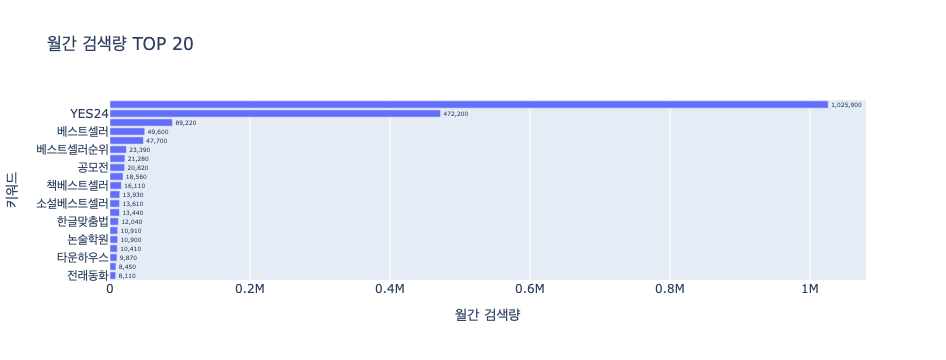

In [51]:
import plotly.express as px

fig = px.bar(
    top_search,
    x="search_total",
    y="keyword",
    orientation="h",
    title="월간 검색량 TOP 20",
    labels={
        "search_total": "월간 검색량",
        "keyword": "키워드",
        "search_pc": "PC 검색량",
        "search_mobile": "Mobile 검색량",
        "competition": "경쟁정도"
    },
    hover_data=[
        "search_pc",
        "search_mobile",
        "competition"
    ],
    text="search_total"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside"
)

fig.show()

In [52]:
top20 = top_search.copy()

In [53]:
top20

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
78,예스24,340700.0,685200.0,200.3,4051.4,0.07,0.63,낮음,1,1025900.0,4251.7,66.790135
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
22,도서관,9220.0,80000.0,7.3,40.9,0.09,0.06,높음,3,89220.0,48.2,89.665994
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323
467,시나공,28600.0,19100.0,29.0,117.8,0.11,0.66,중간,3,47700.0,146.8,40.041929
94,베스트셀러순위,3790.0,19600.0,33.8,419.0,0.92,2.28,높음,10,23390.0,452.8,83.796494
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850
70,공모전,9520.0,11300.0,48.8,124.2,0.54,1.16,높음,10,20820.0,173.0,54.274736
9,책추천,3360.0,15200.0,2.3,35.5,0.07,0.25,높음,10,18560.0,37.8,81.896552
5,책베스트셀러,3010.0,13100.0,30.2,314.7,1.03,2.56,높음,10,16110.0,344.9,81.315953


In [55]:
top20_device = top20.melt(
    id_vars="keyword",
    value_vars=[
        "search_pc",
        "search_mobile"
    ],
    var_name="device",
    value_name="search_volume"
)

top20_device.head()

# 데이터라는 것은 처음 조회 : 큰 덩어리를 위주로 살펴봄 (조회) => 숲을 먼저 보는 개념
# 두번째부터 숲안에 있는 세부적인 요소를 조회

,keyword,device,search_volume
0,예스24,search_pc,340700.0
1,YES24,search_pc,168900.0
2,도서관,search_pc,9220.0
3,베스트셀러,search_pc,13000.0
4,시나공,search_pc,28600.0


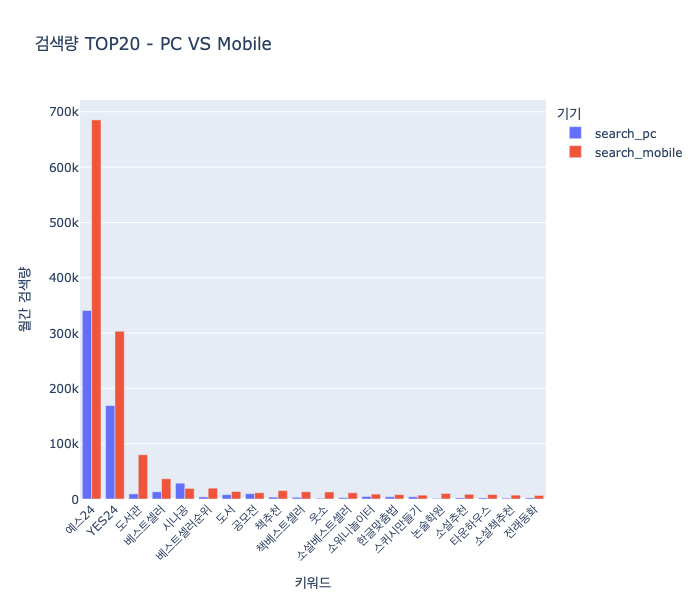

In [61]:
fig = px.bar(
    top20_device,
    x="keyword",
    y="search_volume",
    barmode="group",
    color="device",

    title = "검색량 TOP20 - PC VS Mobile",

    labels = {
        "keyword": "키워드",
        "search_volume": "월간 검색량",
        "device": "기기"
    }
)

fig.update_layout(
    xaxis_tickangle= -45,
    height=600
)

fig.show()

In [62]:
# 최초 : 전체 검색키워드 상위 20개
# 두번째 : 상위 20개 키워드의 기기별 검색빈도 -> 모바일 압승
# 세번째 : 전체 검색키워드 = 검색량 1000건 이상인 조건 해당
# 네번째 : 단순 검색량만 높은게 아니라, 클릭빈도 = 클릭률이 높은 키워드 & 모바일 검색수가 500이상

mobile_keywords = (
    df[df["search_total"] >= 1000]
    .sort_values(
        "mobile_ratio", ascending=False
    ).head(20)
    .copy()
)
# copy() => pandas 문법 : 어떤 필터링, 조건을 적용 -> 원본값이 변경 x // 별도로 생성.저장 관리

In [64]:
mobile_keywords[
    [
        "keyword",
        "search_total",
        "search_mobile",
        "mobile_ratio"
    ]
].round(2)

,keyword,search_total,search_mobile,mobile_ratio
381,말이야와친구들,3550.0,3400.0,95.77
938,국어문제집,1900.0,1750.0,92.11
153,논술학원,10900.0,9970.0,91.47
438,웃소,13930.0,12700.0,91.17
614,독서학원,1210.0,1100.0,90.91
964,읽으면서바로써먹는,2380.0,2150.0,90.34
499,코믹스,2430.0,2190.0,90.12
722,논술준비,1290.0,1160.0,89.92
22,도서관,89220.0,80000.0,89.67
632,초1추천도서,1390.0,1240.0,89.21


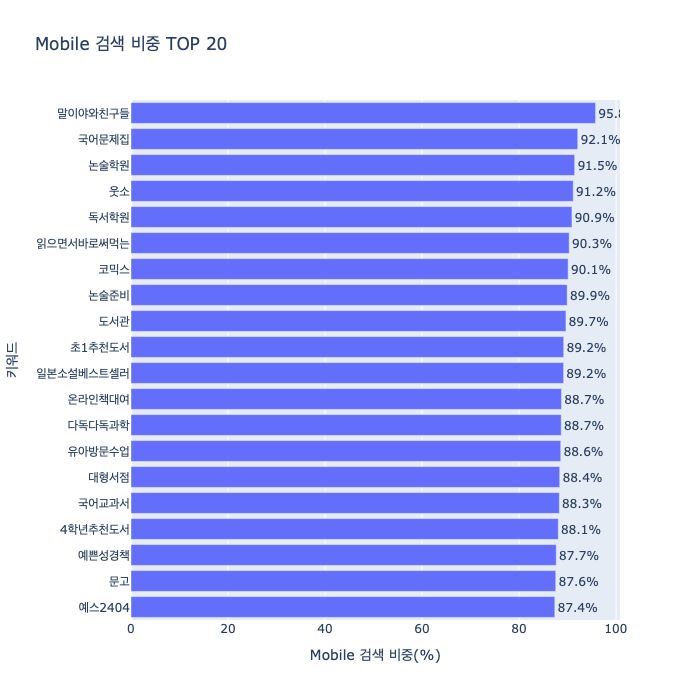

In [69]:
fig = px.bar(
    mobile_keywords,
    x="mobile_ratio",
    y="keyword",
    orientation="h",
    
    title="Mobile 검색 비중 TOP 20",

    labels={
        "keyword": "키워드",
        "mobile_ratio": "Mobile 검색 비중(%)",
        "search_total": "전체 검색량"
    },

    hover_data=[
        "search_total",
        "search_mobile"
    ],

    text="mobile_ratio"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=700
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.show()

In [84]:
top_ctr_mobile = (
    df[(df["search_mobile"] >= 500) & (df["competition"] == "낮음")]
    .sort_values(
        "ctr_mobile",
        ascending=False
    )
    .head(20)
    .copy()
)

In [85]:
top_ctr_mobile

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio
148,YES2404,350.0,1200.0,1.0,16.9,0.31,1.53,낮음,2,1550.0,17.9,77.419355
862,도요새잉글리쉬,190.0,1100.0,0.0,7.8,NaN,0.76,낮음,2,1290.0,7.8,85.271318
78,예스24,340700.0,685200.0,200.3,4051.4,0.07,0.63,낮음,1,1025900.0,4251.7,66.790135
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258
412,이형재행정학,160.0,510.0,0.0,0.0,NaN,NaN,낮음,0,670.0,0.0,76.119403
511,전한길한국사,130.0,650.0,0.0,0.0,NaN,NaN,낮음,0,780.0,0.0,83.333333
868,저자,410.0,1150.0,0.0,0.0,NaN,NaN,낮음,0,1560.0,0.0,73.717949


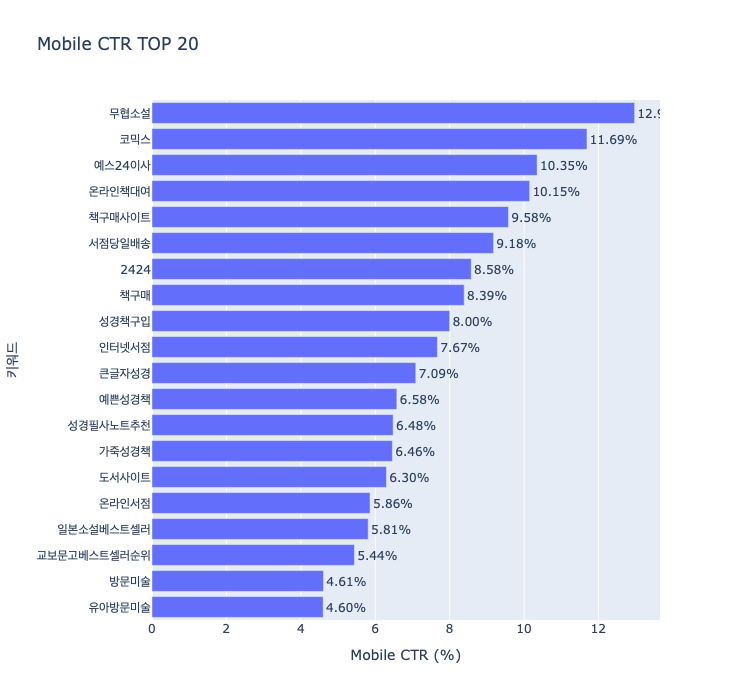

In [80]:
fig = px.bar(
    top_ctr_mobile,
    x="ctr_mobile",
    y="keyword",
    orientation="h",

    title="Mobile CTR TOP 20",

    labels={
        "keyword": "키워드",
        "ctr_mobile": "Mobile CTR (%)",
        "search_mobile": "Mobile 검색량"
    },

    hover_data = [
        "search_mobile",
        "click_mobile",
        "competition"
    ],

    text="ctr_mobile"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    },
    height=700
)

fig.show()

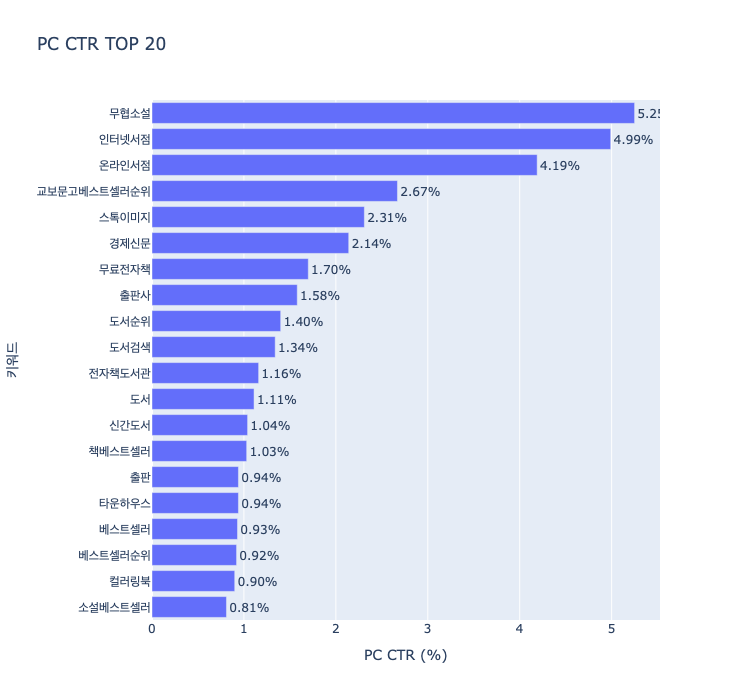

In [88]:
top_ctr_pc = (
    df[df["search_pc"] >= 500]
    .sort_values(
        "ctr_pc",
        ascending=False
    )
    .head(20)
    .copy()
)

fig = px.bar(
    top_ctr_pc,
    x="ctr_pc",
    y="keyword",
    orientation="h",

    title="PC CTR TOP 20",

    labels={
        "keyword": "키워드",
        "ctr_pc": "PC CTR (%)",
        "search_pc": "PC 검색량"
    },

    hover_data = [
        "search_pc",
        "click_pc",
        "competition"
    ],

    text="ctr_pc"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    },
    height=700
)

fig.show()

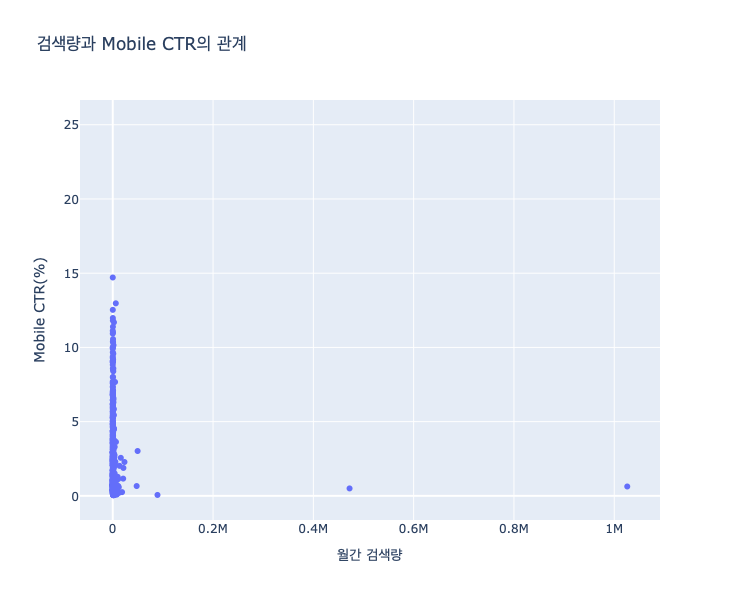

In [92]:
# 산점도 차트
# 점을 흩뿌려서 만든 차트
# 밀(집)도 => 어느 한 구간에 많이 몰려있다
# 데이터 패턴 => 어느 구간, 어떤 타겟, 가격, 시간, 장소 등을 선호

# 차트 목적에 맞춰서 사용!!
# 범주형 데이터 : 남.여 / 10대.20대.30대 / 내국인.외국인
# 절대빈도 값 조회.분석 : 절대값 => 막대그래프 차트
# 상대빈도 값 조회.분석 : 상대값 => 원형 = 파이차트 // 도넛차트
# 시계열 데이터 : 시간 경과에 따라서 값의 변화가 존재할 수 있는 데이터
# 주식차트, 부동산 전월세 임대비
# 꺾은선 차트

fig = px.scatter(
    df,
    x="search_total",
    y="ctr_mobile",

    title = "검색량과 Mobile CTR의 관계",

    labels={
        "search_total": "월간 검색량",
        "ctr_mobile": "Mobile CTR(%)",
        "keyword": "키워드"
    },

    hover_name="keyword",

    hover_data=[
        "search_pc",
        "search_mobile",
        "competition"
    ]
)

fig.update_layout(
    height=600
)

fig.show()

In [93]:
df["search_total"].corr(df["ctr_mobile"])
# corr = correlation = 상관관계
# 상관계수 = -1 (음의상관관계) ~ 0 ~ 1 (양의상관관계)

np.float64(-0.04458516703536996)

In [ ]:
# 로그 스케일 = log scale = 

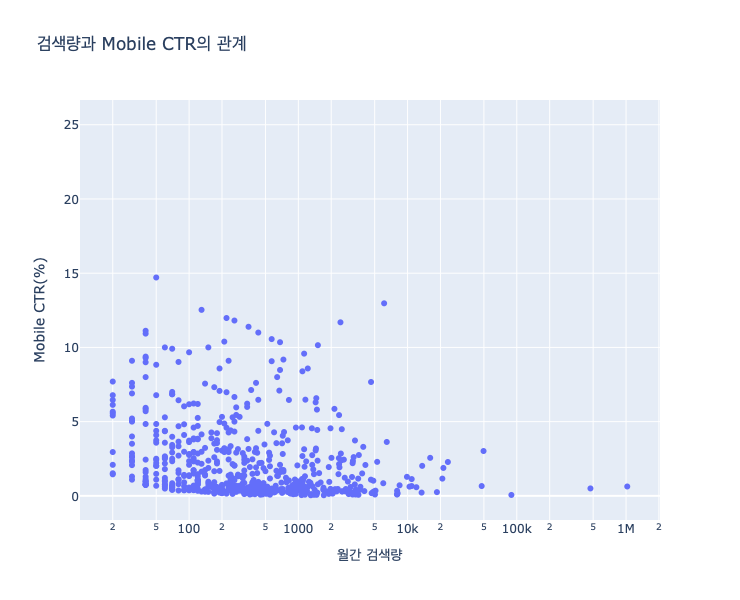

In [95]:
fig = px.scatter(
    df,
    x="search_total",
    y="ctr_mobile",
    log_x=True,

    title = "검색량과 Mobile CTR의 관계",

    labels={
        "search_total": "월간 검색량",
        "ctr_mobile": "Mobile CTR(%)",
        "keyword": "키워드"
    },

    hover_name="keyword",

    hover_data=[
        "search_pc",
        "search_mobile",
        "competition"
    ]
)

fig.update_layout(
    height=600
)

fig.show()

특정 키워드의 경우, 월간 전체 검색량 대비 모바일 클릭율이 비례해서 증가하는 양의 상관관계를 가지고 있으나,
전체적으로 월간 검색량과 모바일 클릭율은 관계가 밀접하게 있다고 보기 어렵다라고 추정(가설)

In [ ]:
# 전체검색량 > 모바일검색량 > 모바일클릭률 > 월간 전체검색량 & 모바일 클릭률 관계
# 경쟁정도 (얼마나 많은 경쟁업체들이 해당 키워드를 놓고 광고 키워드 선점을 위해 경쟁하고 있는가)
# 현재 1000개 키워드는 모두 각각 경쟁정도 값 가지고 있음
# 1000개 키워드들이 각각 경쟁정도 비율이 어떻게 되는지 확인!!

In [99]:
competition_count = df["competition"].value_counts().reset_index()

In [100]:
competition_count

,competition,count
0,높음,833
1,중간,132
2,낮음,35


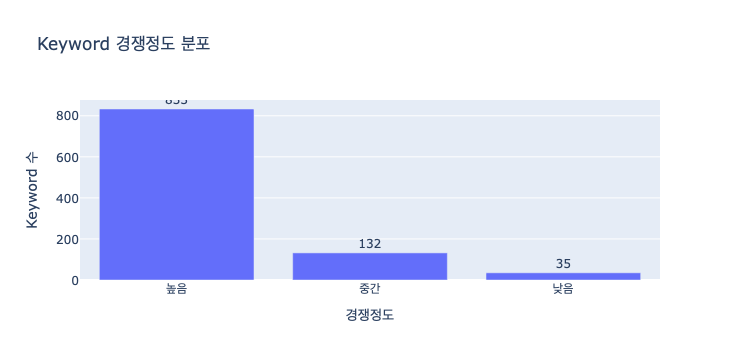

In [102]:
fig = px.bar(
    competition_count,
    x="competition",
    y="count",

    title="Keyword 경쟁정도 분포",

    labels={
        "competition": "경쟁정도",
        "count": "Keyword 수"
    },

    text="count"
)

fig.update_traces(textposition="outside")

fig.show()

In [109]:
competition_ratio = (
    df["competition"]
    .value_counts(normalize=True)
    .mul(100) # multiply
    .reset_index()
)

competition_ratio.columns = ["competition", "ratio"]

In [110]:
competition_ratio

,competition,ratio
0,높음,83.3
1,중간,13.2
2,낮음,3.5


In [122]:
competition_summary = df.groupby("competition").agg(
    keyword_count=("keyword", "count"),
    avg_search=("search_total", "mean"),
    median_search=("search_total", "median"),
    avg_ctr_mobile=("ctr_mobile", "mean")
).reset_index().round(2)

In [123]:
competition_summary

,competition,keyword_count,avg_search,median_search,avg_ctr_mobile
0,낮음,35,107574.29,560.0,3.31
1,높음,833,1141.35,250.0,2.63
2,중간,132,1690.00,265.0,3.40


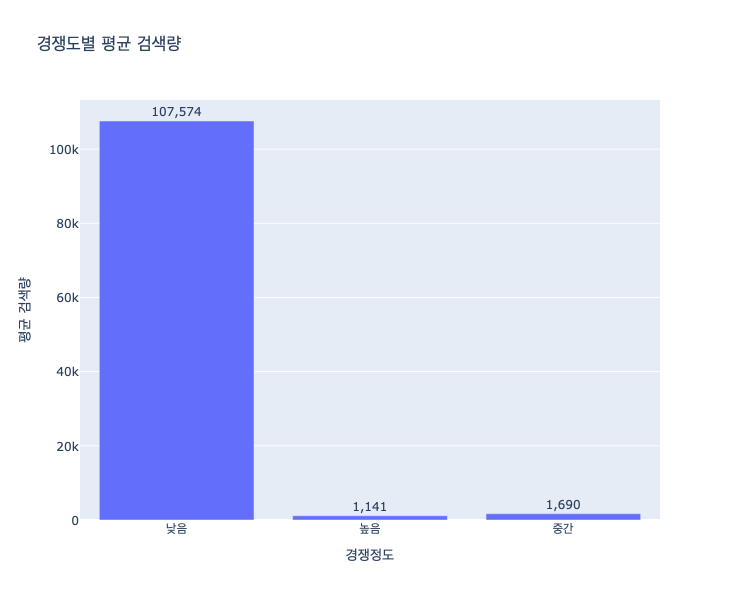

In [127]:
fig = px.bar(
    competition_summary,
    x="competition",
    y="avg_search",

    title="경쟁도별 평균 검색량",

    labels={
        "competition": "경쟁정도",
        "avg_search": "평균 검색량"
    },

    text="avg_search"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(height=600)

fig.show()

In [128]:
# 낮음, 높음, 중간 => 문자열 => 정량 데이터 x

competition_map = {
    "낮음": 1,
    "중간": 2,
    "높음": 3
}

df["competition_score"] = df["competition"].map(competition_map)

In [129]:
df

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio,competition_score
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850,3
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739,3
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258,1
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323,3
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,난책읽기가좋아2단계,20.0,120.0,0.1,2.0,0.68,1.74,중간,7,140.0,2.1,85.714286,2
996,너도하늘말나리야,160.0,680.0,0.0,0.0,NaN,NaN,높음,3,840.0,0.0,80.952381,3
997,국어문제,60.0,250.0,0.4,2.0,0.69,0.84,높음,10,310.0,2.4,80.645161,3
998,무료한글공부,30.0,10.0,0.3,0.0,0.80,NaN,높음,7,40.0,0.3,25.000000,3


In [ ]:
# 전체검색량 > 모바일검색량 > 모바일클릭율 > 경쟁정도

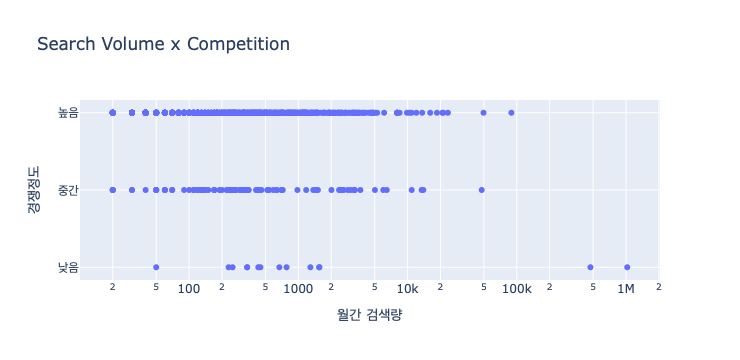

In [135]:
fig = px.scatter(
    df,
    x="search_total",
    y="competition_score",
    # log_x=True,

    title="Search Volume x Competition",

    labels={
        "search_total": "월간 검색량",
        "competition_score": "경쟁정도"
    },

    hover_name="keyword",

    hover_data = [
        "competition",
        "ctr_mobile",
        "ad_count"
    ]
)

fig.update_yaxes(
    tickvals=[1, 2, 3],
    ticktext=["낮음", "중간", "높음"]
)

fig.update_xaxes(
    type="log"
)

fig.show()

# 위 산점도 차트를 통해서 낮음, 중간, 높음의 요소들이 전반적으로 어디에 밀집해있는지, 밀도

In [140]:
# Min-Max Scaling (최소-최대 정규화)

df["search_score"] = (
    df["search_total"] - df["search_total"].min()
) / (
    df["search_total"].max() - df["search_total"].min()
)
# df["search_total"].max()
# df["search_total"].min()

# log scale => 월간검색량 scope (범위)
# 20 ~ 1025900
# 0 ~ 1 (20, 50) 

"""

0 ~ 1 점수 환산 = (현재값 - 최소값) / (최대값 - 최소값)
"""


'\n\n0 ~ 1 점수 환산 = (현재값 - 최소값) / (최대값 - 최소값)\n'

In [142]:
df["ctr_score"] = (
    df["ctr_mobile"] - df["ctr_mobile"].min()
) / (
    df["ctr_mobile"].max() - df["ctr_mobile"].min()
)

In [143]:
df.head()

,keyword,search_pc,search_mobile,click_pc,click_mobile,ctr_pc,ctr_mobile,competition,ad_count,search_total,click_total,mobile_ratio,competition_score,search_score,ctr_score
0,도서,7780.0,13500.0,84.0,239.2,1.11,1.88,높음,10,21280.0,323.2,63.439850,3,0.020724,0.073718
1,독서,1070.0,3840.0,0.5,10.4,0.05,0.29,높음,10,4910.0,10.9,78.207739,3,0.004767,0.010016
2,YES24,168900.0,303300.0,111.0,1412.0,0.08,0.50,낮음,1,472200.0,1523.0,64.231258,1,0.460268,0.018429
3,베스트셀러,13000.0,36600.0,118.6,1031.9,0.93,3.02,높음,10,49600.0,1150.5,73.790323,3,0.048329,0.119391
4,인터넷서점,1620.0,3010.0,78.3,218.8,4.99,7.67,높음,10,4630.0,297.1,65.010799,3,0.004494,0.305689


In [ ]:
EDA
수집한 데이터를 활용한 해당 데이터 안에 있는 인사이트 도출
인사이트를 도출 과정 시각화 -> 마케팅적으로 어떻게 해석
주요 키워드 추출

LDA
